# 🔬 Cancer Image Classification with InceptionV3

This notebook builds a **transfer-learning pipeline** on top of **InceptionV3** (pretrained on ImageNet)  
to classify breast-ultrasound images from the **BUSI dataset** into three categories:  
`benign` · `malignant` · `normal`

---
**Pipeline overview**
1. Import libraries
2. Define constants & transforms
3. Load & visualise the raw dataset
4. Filter out mask images
5. Split into train / test subsets (with augmentation only on train)
6. Build DataLoaders
7. Visualise batches


## 1 · Import Libraries


In [182]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import max, no_grad, manual_seed,save

import torchvision.transforms as transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data import random_split, Subset
from torch.utils.data.dataloader import DataLoader


## 2 · Constants & Transforms


In [180]:
# ── Dataset path ──────────────────────────────────────────────────────────────
PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Cancer Images Dataset\Dataset_BUSI_with_GT"

# ── Image settings ────────────────────────────────────────────────────────────
IMG_SIZE    = (299, 299)   # InceptionV3 expects 299×299 input
PERMUTE_SIZE = (1, 2, 0)  # CHW → HWC for matplotlib

# ── Split ratio ───────────────────────────────────────────────────────────────
SPLIT_SIZES = [0.8, 0.2]  # 80 % train · 20 % test

# ── Model settings ────────────────────────────────────────────────────────────
PRETRAINED     = True
NUM_OF_CLASSES = 3        # benign · malignant · normal
PATIENCE = 3
BEST_VAL_LOSS = float('inf')

# ── DataLoader settings ───────────────────────────────────────────────────────
BATCH_SIZE = 20
EPOCHS     = 10

# ── Transforms ────────────────────────────────────────────────────────────────
# Train: includes augmentation to improve generalisation
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),                          # resize to InceptionV3 input size
    transforms.ColorJitter(brightness=[0.5, 1.8]),        # random brightness shift
    transforms.GaussianBlur(kernel_size=(3, 3)),          # slight blur for robustness
    transforms.RandomCrop((280, 280)),                    # random spatial crop
    transforms.ToTensor(),                                # PIL → FloatTensor [0,1]
])

# Test: only resize + tensor (no augmentation — we evaluate on clean images)
TEST_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

# ── Quick sanity-check: list top-level folders in the dataset ─────────────────
os.listdir(PATH)


['benign', 'malignant', 'normal']

## 3 · Load Dataset & Visualise Random Samples


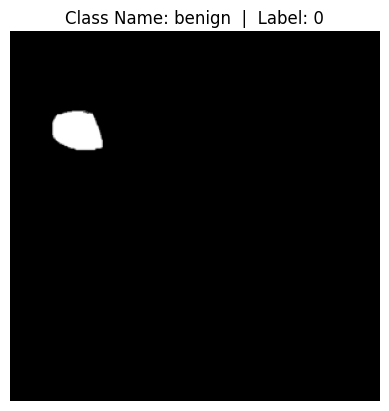

In [174]:
# Load full dataset with TEST transforms (no augmentation) just for exploration
dataset = ImageFolder(PATH, TEST_TRANSFORMS)

def Show_Random_Image(dataset):
    """Pick a random sample from *dataset* and display it with its class label."""
    idx = np.random.randint(len(dataset))
    img, label = dataset[idx]

    plt.imshow(img.permute(PERMUTE_SIZE))
    
    class_name = dataset.classes[label]

    plt.title(f"Class Name: {class_name}  |  Label: {label}")
    plt.axis("off")
    plt.show()

Show_Random_Image(dataset)


## 4 · Filter Mask Images & Split into Train / Test

The BUSI dataset ships each scan paired with a `_mask` PNG.  
We keep **only the original scans** (paths that do **not** contain the word `mask`).

> **Why two `ImageFolder` calls?**  
> `ImageFolder` stores one transform for the whole dataset.  
> The cleanest way to have different transforms for train vs test is to load the  
> same folder twice — each with its own `Compose` — then assign disjoint index  
> slices via `Subset`.


In [175]:
# ── Step 1: collect indices of real scans (exclude mask images) ───────────────
base_dataset = ImageFolder(PATH)

dataset_valid_indices = [
    i for i, (path, _) in enumerate(base_dataset.samples)
    if "mask" not in path
]

# ── Step 2: deterministic 80/20 index split ───────────────────────────────────
train_size    = int(SPLIT_SIZES[0] * len(dataset_valid_indices))
train_indices = dataset_valid_indices[:train_size]
test_indices  = dataset_valid_indices[train_size:]

# ── Step 3: build two ImageFolder objects with DIFFERENT transforms ────────────
# train_ds → augmentation ON  |  test_ds → augmentation OFF
train_ds = Subset(ImageFolder(PATH, TRAIN_TRANSFORMS), train_indices)
test_ds  = Subset(ImageFolder(PATH, TEST_TRANSFORMS),  test_indices)

print(f"Train samples : {len(train_ds)}")
print(f"Test  samples : {len(test_ds)}")


Train samples : 624
Test  samples : 156


In [ ]:
# ── Sanity check: confirm each split uses the correct transform pipeline ───────
print("Train transform:\n", train_ds.dataset.transform)
print()
print("Test transform:\n",  test_ds.dataset.transform)


Train transform:
 Compose(
    Resize(size=(299, 299), interpolation=bilinear, max_size=None, antialias=True)
    ColorJitter(brightness=(0.5, 1.8), contrast=None, saturation=None, hue=None)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
    RandomCrop(size=(280, 280), padding=None)
    ToTensor()
)

Test transform:
 Compose(
    Resize(size=(299, 299), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## 5 · Build DataLoaders


In [177]:
# shuffle=True on train to break ordering bias each epoch
# shuffle=False on test for reproducible evaluation
train_dl = DataLoader(dataset=train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(dataset=test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_dl)}")
print(f"Test  batches : {len(test_dl)}")


Train batches : 32
Test  batches : 8


## 6 · Visualise Image Batches


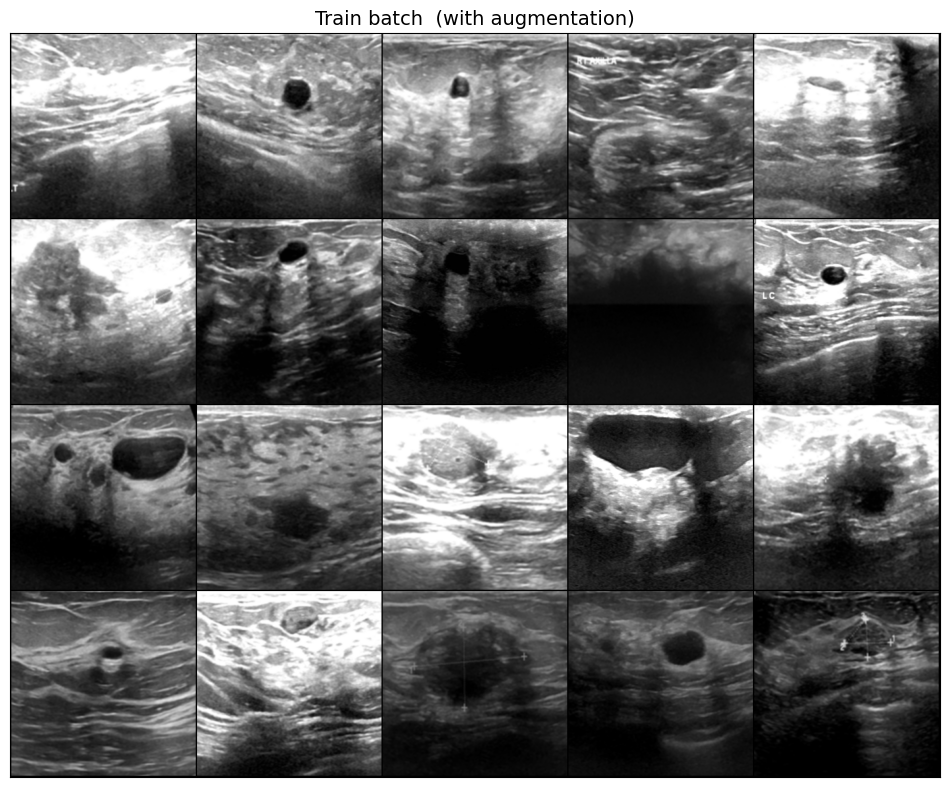

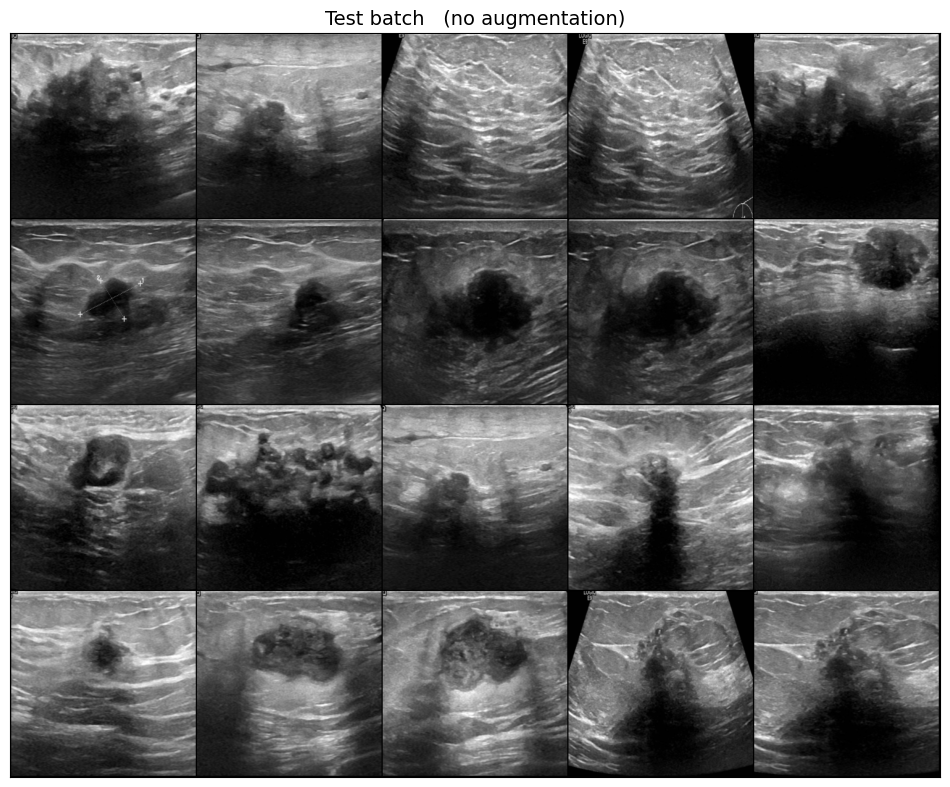

In [178]:
def Show_Grid_Of_Images(dl, title=""):
    """Display the first batch from *dl* as an image grid (5 images per row)."""
    _, ax = plt.subplots(figsize=(12, 10))
    imgs, labels = next(iter(dl))
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(title, fontsize=14)
    ax.imshow(make_grid(imgs, nrow=5).permute(PERMUTE_SIZE))
    plt.show()

# Train batch — should look varied due to augmentation
Show_Grid_Of_Images(train_dl, title="Train batch  (with augmentation)")

# Test batch — should look clean, no augmentation
Show_Grid_Of_Images(test_dl,  title="Test batch   (no augmentation)")


In [ ]:
model = inception_v3(weights=Inception_V3_Weights)

model.fc = nn.Linear(model.fc.in_features,NUM_OF_CLASSES)

In [ ]:
opt = optim.AdamW(model.parameters(),lr=1e-4)

In [ ]:
from tqdm import tqdm

history = []

for epoch in range(EPOCHS):
    train_all_loss= []
    train_all_acc= []

    model.train()

    for imgs,labels in tqdm(train_dl,desc=f"Epoch: {epoch+1}/{EPOCHS}"):
        outputs = model(imgs)

        if hasattr(outputs, 'logits'):
            outputs = outputs.logits

        loss = F.cross_entropy(outputs,labels)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_all_loss.append(loss.item())
        _,preds = max(outputs,dim=1)
        train_all_acc.append((preds == labels).float().mean().item())

    train_loss = sum(train_all_loss) / len(train_all_loss)
    train_acc = sum(train_all_acc) / len(train_all_acc)

    test_all_loss= []
    test_all_acc= []

    model.eval()
    with no_grad():
        for imgs,labels in test_dl:
            outputs = model(imgs)

            if hasattr(outputs, 'logits'):
                outputs = outputs.logits

            loss = F.cross_entropy(outputs,labels)
            loss.backward()
            opt.step()
            opt.zero_grad()

            test_all_loss.append(loss.item())
            _ , preds = max(outputs,dim=1)
            test_all_acc.append((preds == labels).float().mean().item())

    test_loss = sum(test_all_loss) / len(test_all_loss)
    test_acc = sum(test_all_acc) / len(test_all_acc)

    print(f"Train_Accuracy: {train_acc:.4f} ── Train_Loss: {train_loss:.4f} ||| Val_Accuracy: ── {test_acc:.4f} Val_Loss: {test_loss:.4f}")

    history.append({
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    if test_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = test_loss
        counter = 0
        save(model.state_dict(), 'best_model.pth')
    else:
        counter+=1
        if counter >= PATIENCE:
            print("Early Stopping!!")
            break